In [1]:
import xarray as xr

path_to_ds = "/home/orgon/Downloads/S5P_NRTI_L2__NO2____20260316T072128_20260316T072628_43639_03_020901_20260316T080448.nc"

ds = xr.open_dataset(path_to_ds, group = "PRODUCT", engine="netcdf4")
print(ds)

<xarray.Dataset> Size: 29MB
Dimensions:                                               (time: 1,
                                                           scanline: 372,
                                                           ground_pixel: 450,
                                                           layer: 34,
                                                           vertices: 2,
                                                           corner: 4,
                                                           polynomial_exponents: 6,
                                                           intensity_offset_polynomial_exponents: 1)
Coordinates:
  * time                                                  (time) datetime64[ns] 8B ...
  * scanline                                              (scanline) float64 3kB ...
  * ground_pixel                                          (ground_pixel) float64 4kB ...
    latitude                                              (time, scanline, ground

In [2]:
from netCDF4 import Dataset

dataset = Dataset(path_to_ds)
print(dataset)

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    Conventions: CF-1.7
    institution: KNMI
    source: Sentinel 5 precursor, TROPOMI, space-borne remote sensing, L2
    history: 2026-03-16 08:07:04 UNKNOWN tropnll2dp /pdgs/storage_nrt/cache_nrt/WORKING-821640117/JobOrder.821638672.xml
    summary: TROPOMI/S5P NO2 5-minute L2 Swath 5.5x3.5km
    tracking_id: d21f644f-142d-44f4-a7c1-6d2ebf9599d7
    id: S5P_NRTI_L2__NO2____20260316T072128_20260316T072628_43639_03_020901_20260316T080448
    time_reference: 2026-03-16T00:00:00Z
    time_reference_days_since_1950: 27833
    time_reference_julian_day: 2461115.5
    time_reference_seconds_since_1970: 1773619200
    time_coverage_start: 2026-03-16T07:21:23Z
    time_coverage_end: 2026-03-16T07:26:34Z
    time_coverage_duration: PT311.633S
    time_coverage_resolution: PT0.840S
    orbit: 43639
    references: https://sentinels.copernicus.eu/web/sentinel/technical-guides/sentinel-5p/products-algorithms; http://ww

In [3]:
print(ds.data_vars)

Data variables:
    delta_time                                            (time, scanline) datetime64[ns] 3kB ...
    time_utc                                              (time, scanline) object 3kB ...
    qa_value                                              (time, scanline, ground_pixel) float32 670kB ...
    nitrogendioxide_tropospheric_column                   (time, scanline, ground_pixel) float32 670kB ...
    nitrogendioxide_tropospheric_column_precision         (time, scanline, ground_pixel) float32 670kB ...
    nitrogendioxide_tropospheric_column_precision_kernel  (time, scanline, ground_pixel) float32 670kB ...
    averaging_kernel                                      (time, scanline, ground_pixel, layer) float32 23MB ...
    air_mass_factor_troposphere                           (time, scanline, ground_pixel) float32 670kB ...
    air_mass_factor_total                                 (time, scanline, ground_pixel) float32 670kB ...
    tm5_tropopause_layer_index           

## Try accessing a data value :
- To get NO2 concentration in tropospheric column, we need to specify where/which column. We can either do this by specifying lat/long, or by specifying scanline/ground_pixel.
- For some reason, `time` only takes the value 0. Perhaps that will change if we consider data from multiple days.
- Setting time = 0, scanline = 6, and ground_pixel = 10, we get the value of NO2 concentration detected by the sensors (on a particular date), at a particular location.

In [4]:
no2 = ds['nitrogendioxide_tropospheric_column']
scanLine = 0 # in range(0, 372+1)
groundPixel = 6 # in range(0, 450+1)
value = no2.isel(time=0, scanline=6, ground_pixel=10)
conc = (float(value))
lat = float(value.latitude)
lon = float(value.longitude)
print(f"At coordinates ~ ({lat:.2f},{lon:.2f}), concentration of NO2 was {conc} mol/m^2.")
print(f"This was found using scanline and ground_pixel values ({scanLine},{groundPixel})")

At coordinates ~ (25.09,76.92), concentration of NO2 was 1.9501589122228324e-05 mol/m^2.
This was found using scanline and ground_pixel values (0,6)


- We can also try to find the concentration and scanline/ground_pixel details using coordinates

In [5]:
lat = 25.09
lon = 76.92
error = 0.01 # if too liberal, you get too many datapoints nearby. If too strict, lat/lon match might not exist in the dataset.
mask0 = (
    (ds.latitude <= lat+error) & (ds.latitude >= lat-error) &
    (ds.longitude <= lon+error) & (ds.longitude >= lon-error)
)
new_no2 = ds['nitrogendioxide_tropospheric_column'].where(mask0, drop=True)
conc = float(new_no2[0,0,0])

print(f"The concentration of NO2 around ({lat}, {lon}) was {conc} mol/m^2.")
print(f"This was found using just lat/lon and some error tuning (guesswork).")

The concentration of NO2 around (25.09, 76.92) was 1.9501589122228324e-05 mol/m^2.
This was found using just lat/lon and some error tuning (guesswork).


[42.0, 84.0, 17.0, 36.0]


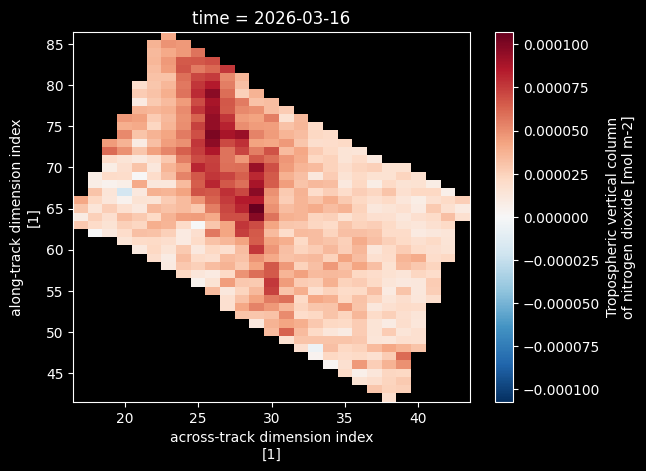

In [6]:
import numpy as np
# Define a simple bounding box (min_lat, max_lat, min_lon, max_lon)
# For a complex polygon, you would use geopandas and shapely.vectorized.contains
lat_min, lat_max = 28.0, 29.39
lon_min, lon_max = 76.3, 79.0
"""
This covers the region between NW : Kaithal and SE : Aligarh.
"""


# Create a mask based on the coordinates in the dataset
mask1 = (
    (ds.latitude >= lat_min) & (ds.latitude <= lat_max) &
    (ds.longitude >= lon_min) & (ds.longitude <= lon_max)
)

subset1 = ds.where(mask1, drop=True)
s_max = float(max(list(subset1["scanline"])))
s_min = float(min(list(subset1["scanline"])))
g_max = float(max(list(subset1["ground_pixel"])))
g_min = float(min(list(subset1["ground_pixel"])))
L = [s_min, s_max-2, g_min, g_max-7] # adjusted to get a decently sized bounding-rhombus. Can do without also.
print(L)

# smol_scan_line = min(list(subset1["ground_pixel"])) # replace ground_pixel with scanline, and min with max to get all corners.
"""
Used mask1 to find the (scanline,ground_pixel) corners that make analysis easier :
"""
mask2 = (
    (ds["scanline"] >= s_min) & (ds["scanline"] <= s_max-2) & (ds["ground_pixel"] <= g_max-7) & (ds["ground_pixel"] >= g_min) # (84-42 + 1)*(36-17 + 1) = 860 squares.
)
subset1.nitrogendioxide_tropospheric_column.plot()

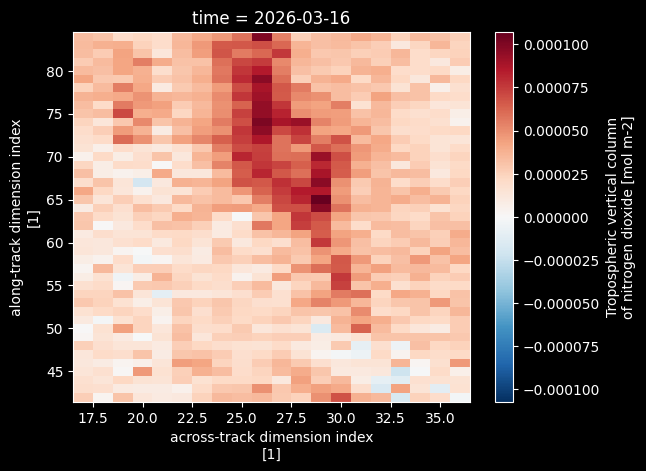

In [7]:
subset2 = ds.where(mask2, drop=True)
subset2.nitrogendioxide_tropospheric_column.plot()

In [8]:
s = [s_max-2, s_min]
gp = [g_max-7, g_min]

for scl in s :
    for g_p in gp :
        J = subset2.sel(scanline = scl, ground_pixel = g_p)
        print(float(J.longitude[0]), ",", float(J.latitude[0]))


77.93844604492188 , 29.9224796295166
75.95340728759766 , 29.01828956604004
78.7144546508789 , 27.916690826416016
76.75715637207031 , 27.030611038208008


- The above data was fed (raw, just copy-paste) into [This website](https://dwtkns.com/pointplotter/) to figure out what the region looks like.
- These may not be actual corners of the region. They are merely the lat/lons of the corner points for `subset2`.

In [9]:
import tensorflow as tf

layers = tf.keras.layers

# 1. Prepare Features (X) and Target (y)
# Usually, you convert the xarray to a pandas dataframe for ML
df = subset2[['nitrogendioxide_tropospheric_column', 'qa_value', 'air_mass_factor_total']].to_dataframe().dropna()

# For prediction, you might use 'nitrogendioxide_tropospheric_column' as your target
# and other metadata/meteorology as features.
X = df[['air_mass_factor_total', 'qa_value']].values
y = df['nitrogendioxide_tropospheric_column'].values

# 2. Define a Simple Neural Network
model = tf.keras.Sequential([
    tf.keras.Input(shape = (X.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1) # Output for regression
])

model.compile(optimizer='adam', loss='mse')
print("Model summary for NO2 prediction:")
model.summary()

I0000 00:00:1775115488.400649    7613 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775115488.404113    7613 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775115488.778114    7613 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775115490.661140    7613 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Model summary for NO2 prediction:


E0000 00:00:1775115490.876512    7613 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

## How to put things together?

- For each value of the tuple (scanline, ground_pixel, time) we have a float (for no2, air mass, etc)
- Training will take place only for a bounding box B. Rest of the data we skip
- Inside B, we can ask for predictions for the region described by one pixel.
- This should depend on the date/time and other parameters as realized in and around that pixel over the past few days.
- Read up on Time Series.

In [10]:
no2 = subset2['nitrogendioxide_tropospheric_column']
values = no2.isel()
print(np.shape(values))

(1, 43, 20)
